<a href="https://colab.research.google.com/github/Musarrat1/tea-house/blob/main/tealeaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive





 Classroom
'Colab Notebooks'
'Cv (2) (1).pdf'
'Cv (2).pdf'
 CV.pdf
 IMG_3124.JPG
 IMG_3180.JPG
 IMG_3349.JPG
 IMG_3389.JPG
 IMG_3399.JPG
 IMG_3401.JPG
 IMG_3404.JPG
 IMG_3409.JPG
 IMG_3410.JPG
 IMG_3411.JPG
 IMG_3418.JPG
 IMG_3447.JPG
 IMG_3459.JPG
 IMG_3468.JPG
 IMG_3479.JPG
 IMG_3817.JPG
 IMG_3818.JPG
 IMG_3820.JPG
 IMG_3824.JPG
 IMG_3827.JPG
 IMG_3828.JPG
 IMG_3831.JPG
 IMG_3832.JPG
 IMG_3864.JPG
 IMG_3865.JPG
 IMG_4508.JPG
 IMG_4512.JPG
 IMG_4773.JPG
 IMG_4973.JPG
 IMG_5072.JPG
 IMG_5078.JPG
 IMG_5081.JPG
 IMG_5090.JPG
 IMG_5140.JPG
 IMG_5141.JPG
 IMG_5148.JPG
 IMG_5190.JPG
 IMG_5197.JPG
 IMG_5201.JPG
 IMG_5203.JPG
 IMG_5265.JPG
 IMG_5266.JPG
 IMG_5267.JPG
 IMG_5268.JPG
 IMG_5273.JPG
 IMG_5496.JPG
 IMG_5497.JPG
 IMG_5498.JPG
 IMG_5577.JPG
 IMG_5598.JPG
 IMG_5631.JPG
 IMG_5666.JPG
 IMG_5669.JPG
 IMG_5735.JPG
 IMG_5791.JPG
 IMG_5824.JPG
 IMG_5826.JPG
 IMG_5853.JPG
 IMG_5855.JPG
 IMG_5866.JPG
 IMG_6043.JPG
 IMG_6174.JPG
 IMG_6194.JPG
 IMG_6238.JPG
 IMG_6243.JPG
 IMG_6353.JPG
 IMG_6356

In [ ]:
!unzip -q "/content/drive/MyDrive/TeaDataset.zip" -d /content/dataset


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import os

DATA_DIR = "/content/dataset/TeaDataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32



In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)



Found 3746 files belonging to 5 classes.
Using 2997 files for training.
Found 3746 files belonging to 5 classes.
Using 749 files for validation.
Classes: ['7. Healthy leaf', 'Brown Blight', 'Grey Blight', 'Helopelties', 'Red rust']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
])


In [ ]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input


In [ ]:
normalization_layer = layers.Rescaling(1./255)


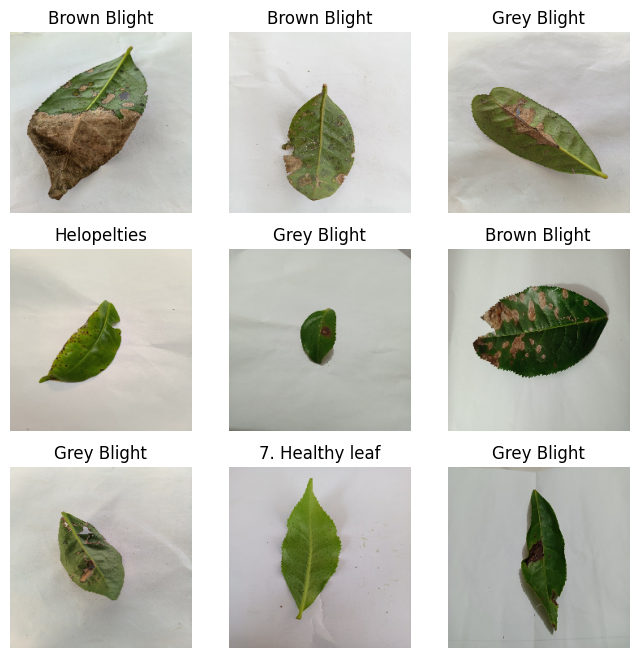

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[tf.argmax(labels[i])])
        plt.axis("off")


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/content/dataset/TeaDataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


Found 3746 files belonging to 5 classes.
Using 2997 files for training.
Found 3746 files belonging to 5 classes.
Using 749 files for validation.
Classes: ['7. Healthy leaf', 'Brown Blight', 'Grey Blight', 'Helopelties', 'Red rust']


In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze backbone

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.4733 - loss: 1.3033 - val_accuracy: 0.7316 - val_loss: 0.7341
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.7109 - loss: 0.7744 - val_accuracy: 0.8117 - val_loss: 0.5770
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 319s 3s/step - accuracy: 0.7558 - loss: 0.6594 - val_accuracy: 0.8051 - val_loss: 0.5352
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 321s 3s/step - accuracy: 0.7772 - loss: 0.6168 - val_accuracy: 0.8238 - val_loss: 0.4899
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.7899 - loss: 0.5676 - val_accuracy: 0.8331 - val_loss: 0.4702
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 413s 4s/step - accuracy: 0.7961 - loss: 0.5368 - val_accuracy: 0.8385 - val_loss: 0.4611
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 352s 4s/step - accuracy: 0.8214 - loss: 0.4937 - val_accuracy: 0.8465 - val_loss: 0.4304
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 369s 3s/step - accuracy: 0.8175 - loss: 0.5102 - val_accuracy: 0.8585 - v

In [ ]:
model.save("tea_leaf_model_final.keras")


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


                 precision    recall  f1-score   support

7. Healthy leaf     0.9381    0.9579    0.9479       190
   Brown Blight     0.6944    0.7500    0.7212       100
    Grey Blight     0.8168    0.8462    0.8312       195
    Helopelties     0.9755    0.9034    0.9381       176
       Red rust     0.7561    0.7045    0.7294        88

       accuracy                         0.8585       749
      macro avg     0.8362    0.8324    0.8336       749
   weighted avg     0.8614    0.8585    0.8593       749



<Figure size 800x800 with 0 Axes>

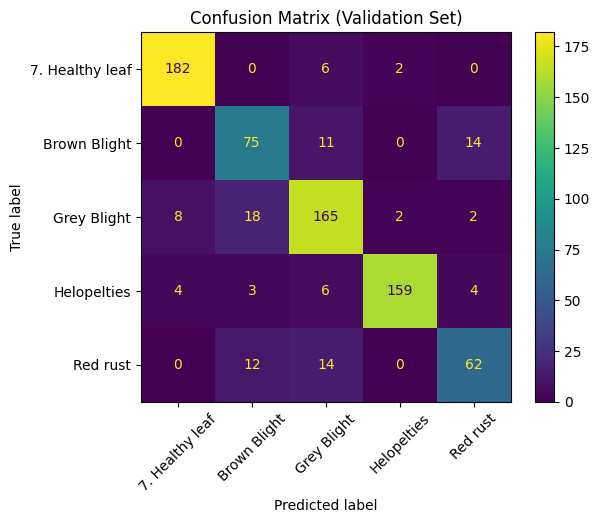

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 8))
disp.plot(values_format='d', xticks_rotation=45)
plt.title("Confusion Matrix (Validation Set)")
plt.show()


In [ ]:
report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)

with open("classification_report.txt", "w") as f:
    f.write("Classes: " + str(class_names) + "\n\n")
    f.write(report_text)

print("Saved: classification_report.txt")


Saved: classification_report.txt


In [ ]:
!cp classification_report.txt /content/drive/MyDrive/
!cp best_model.keras /content/drive/MyDrive/
print("Copied report + model to MyDrive")


Copied report + model to MyDrive


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# take one batch
images, labels = next(iter(val_ds))
img = images[0]
true_label = np.argmax(labels[0].numpy())
print("True:", class_names[true_label])


True: Grey Blight


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

base = model.get_layer("efficientnetb0")

last_conv_layer_name = None
for layer in reversed(base.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last conv layer:", last_conv_layer_name)

Last conv layer: top_conv


In [ ]:
conv_model = tf.keras.Model(
    inputs=base.input,
    outputs=base.get_layer(last_conv_layer_name).output
)


In [ ]:
def gradcam_heatmap_manual(img_tensor):
    """
    img_tensor: float tensor shape (1,224,224,3) in range 0..255 (same as your dataset batch)
    """
    # Apply SAME preprocessing you used in training (EfficientNet preprocess)
    x = tf.keras.applications.efficientnet.preprocess_input(img_tensor)

    with tf.GradientTape() as tape:
        # Forward through EfficientNet up to last conv
        conv_outputs = conv_model(x)
        tape.watch(conv_outputs)

        # Forward through your model "head" manually
        pooled = model.get_layer("global_average_pooling2d")(conv_outputs)
        dropped = model.get_layer("dropout")(pooled, training=False)
        preds = model.get_layer("dense")(dropped)

        top_class = tf.argmax(preds[0])
        class_score = preds[:, top_class]

    # Gradients of top predicted class w.r.t conv outputs
    grads = tape.gradient(class_score, conv_outputs)

    # Global average pooling of grads
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(top_class.numpy())


In [ ]:
def show_gradcam(img, heatmap, alpha=0.4):
    img_uint8 = tf.cast(img, tf.uint8).numpy()

    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_uint8 = np.expand_dims(heatmap_uint8, axis=-1)
    heatmap_uint8 = tf.image.resize(heatmap_uint8, (img_uint8.shape[0], img_uint8.shape[1])).numpy()
    heatmap_uint8 = np.repeat(heatmap_uint8, 3, axis=-1)

    overlay = np.clip((1 - alpha) * img_uint8 + alpha * heatmap_uint8, 0, 255).astype(np.uint8)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img_uint8); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Heatmap"); plt.imshow(heatmap, cmap="jet"); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
    plt.show()



Image 0 | True: Grey Blight | Pred: 7. Healthy leaf


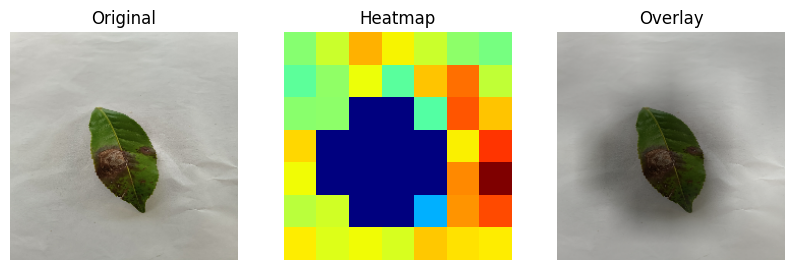


Image 1 | True: Grey Blight | Pred: Grey Blight


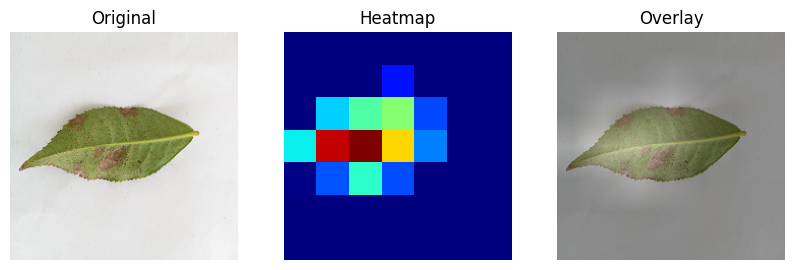


Image 2 | True: 7. Healthy leaf | Pred: 7. Healthy leaf


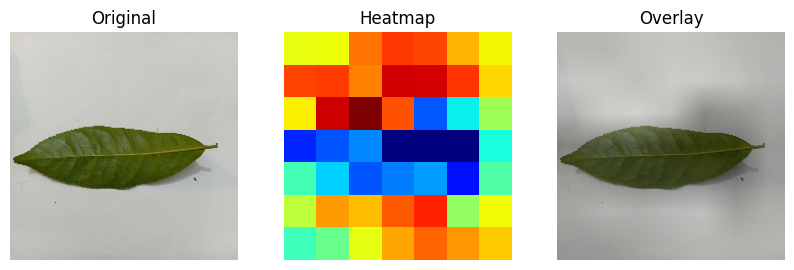

In [ ]:
images, labels = next(iter(val_ds))

for idx in [0, 1, 2]:
    img = images[idx]
    true_label = np.argmax(labels[idx].numpy())

    img_tensor = tf.expand_dims(img, axis=0)  # (1,224,224,3)

    heatmap, pred_label = gradcam_heatmap_manual(img_tensor)

    print(f"\nImage {idx} | True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
    show_gradcam(img, heatmap)


In [ ]:
def make_gradcam_heatmap_nested(img_array, model, base_layer_name, last_conv_layer_name, pred_index=None):
    base_model = model.get_layer(base_layer_name)
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Model that maps input -> (last conv activations, predictions)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


In [ ]:
print(model.layers)
print(base.input.shape, base.output.shape)



[<InputLayer name=input_layer_1, built=True>, <Sequential name=sequential_1, built=True>, <Functional name=efficientnetb0, built=True>, <GlobalAveragePooling2D name=global_average_pooling2d, built=True>, <Dropout name=dropout, built=True>, <Dense name=dense, built=True>]
(None, 224, 224, 3) (None, 7, 7, 1280)



Image 0 | True: Grey Blight | Pred: 7. Healthy leaf


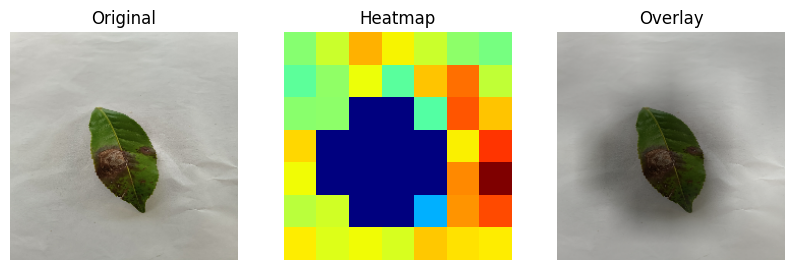


Image 1 | True: Grey Blight | Pred: Grey Blight


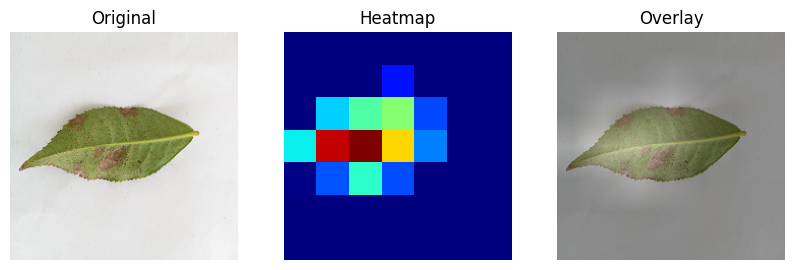


Image 2 | True: 7. Healthy leaf | Pred: 7. Healthy leaf


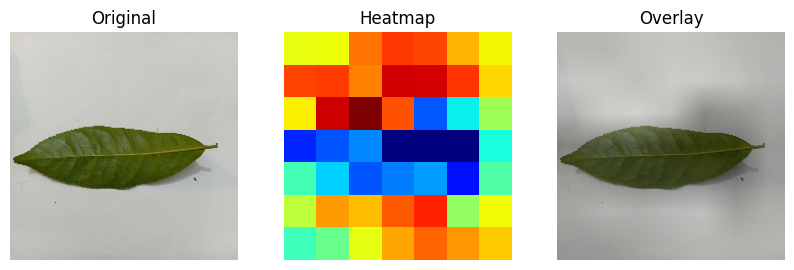

In [ ]:
images, labels = next(iter(val_ds))

for idx in [0, 1, 2]:
    img = images[idx]
    true_label = np.argmax(labels[idx].numpy())

    img_tensor = tf.expand_dims(img, axis=0)  # (1,224,224,3)

    heatmap, pred_label = gradcam_heatmap_manual(img_tensor)

    print(f"\nImage {idx} | True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
    show_gradcam(img, heatmap)


In [ ]:
import os, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt

os.makedirs("gradcam_outputs", exist_ok=True)

def save_gradcam_triplet(img, heatmap, title, save_path, alpha=0.4):
    img_uint8 = tf.cast(img, tf.uint8).numpy()

    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_uint8 = np.expand_dims(heatmap_uint8, axis=-1)
    heatmap_uint8 = tf.image.resize(heatmap_uint8, (img_uint8.shape[0], img_uint8.shape[1])).numpy()
    heatmap_uint8 = np.repeat(heatmap_uint8, 3, axis=-1)

    overlay = np.clip((1 - alpha) * img_uint8 + alpha * heatmap_uint8, 0, 255).astype(np.uint8)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img_uint8); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Heatmap"); plt.imshow(heatmap, cmap="jet"); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()

images, labels = next(iter(val_ds))

for idx in [0,1,2]:
    img = images[idx]
    true_label = np.argmax(labels[idx].numpy())
    img_tensor = tf.expand_dims(img, axis=0)

    heatmap, pred_label = gradcam_heatmap_manual(img_tensor)

    title = f"Idx {idx} | True: {class_names[true_label]} | Pred: {class_names[pred_label]}"
    save_path = f"gradcam_outputs/gradcam_{idx}.png"
    save_gradcam_triplet(img, heatmap, title, save_path)

print("Saved in: gradcam_outputs/")


Saved in: gradcam_outputs/


In [ ]:
!cp -r gradcam_outputs /content/drive/MyDrive/


In [ ]:
remedy = {
    "Healthy": "Leaf is healthy. Maintain regular monitoring and good field hygiene.",
    "BrownBlight": "Remove infected leaves, improve air flow, avoid overhead irrigation, apply recommended fungicide (as per BTRI guidance).",
    "GreyBlight": "Prune infected parts, ensure drainage, reduce humidity, apply suitable fungicide if severe.",
    "RedRust": "Improve sunlight exposure, prune/shade control, apply copper-based spray if needed.",
    "Helopeltis": "Use IPM: monitoring, pruning, and neem-based spray / recommended insect control method if infestation increases."
}

# Example prediction output text:
predicted_class = "GreyBlight"
print("Prediction:", predicted_class)
print("Suggested action:", remedy.get(predicted_class, "Consult an agronomist."))


Prediction: GreyBlight
Suggested action: Prune infected parts, ensure drainage, reduce humidity, apply suitable fungicide if severe.


In [ ]:
model.save("tea_leaf_model_final.keras")

# if Drive mounted
!cp tea_leaf_model_final.keras /content/drive/MyDrive/
!cp classification_report.txt /content/drive/MyDrive/


In [ ]:
history.history["val_accuracy"][-1]


0.8571428656578064

In [ ]:
save_dir = '/content/drive/MyDrive/tea_leaf_preprocessed'

os.makedirs(save_dir, exist_ok=True)

i = 0
for batch in datagen.flow_from_directory(dataset_path, target_size=IMG_SIZE, batch_size=1, save_to_dir=save_dir, save_format='jpg'):
    i += 1
    if i > 100:  # save 100 preprocessed images
        break
